In [1]:
from pathlib import Path
import pandas as pd
import sys

sys.path.append(r"../src")
from analysis_pipeline import collect_results, apply_hr_eit_corrections
from contribution_signal import run_contribution_to_signal_analysis

sys.path.append(r"../src")
from visualization import bland_altman_plot

## Saving data

In [ ]:
patients = ["002", "004", "005", "006", "009", "010", "011", "012", "014", "015", "016", "017", "018"]

phases = ["preswitch", "t0", "t30", "t60", "t90", "t120", "t150", "t180", "t210"]

fs = 256

sync_base = ... # Path naar gesynchronizeerde data
PROJECT_ROOT = ... # Path naar output

OUTPUT_DIR = PROJECT_ROOT / "outputs"

output_csv = OUTPUT_DIR / "output_df.csv"
output_csv_corrected = OUTPUT_DIR / "output_df_HR_EIT_corrected.csv"

bland_altman_save_path = OUTPUT_DIR / "bland_altman_HR_CGO_vs_HR_EIT.png"
bland_altman_save_path_corrected = OUTPUT_DIR / "bland_altman_HR_CGO_vs_HR_EIT_corrected.png"
contribution_results_dir = OUTPUT_DIR / "contribution_results"

In [9]:
df_output, errors = collect_results(
    patients=patients,
    phases=phases,
    sync_base=sync_base,
    fs=fs,
    output_csv=output_csv,
)

if errors:
    print("\nErrors:")
    for err in errors:
        print(err)

OK: patient 002, phase preswitch
OK: patient 002, phase t0
OK: patient 002, phase t30
OK: patient 002, phase t60
OK: patient 002, phase t90
OK: patient 002, phase t120
OK: patient 002, phase t150
OK: patient 002, phase t180
OK: patient 002, phase t210
OK: patient 004, phase preswitch
OK: patient 004, phase t0
OK: patient 004, phase t30
OK: patient 004, phase t60
OK: patient 004, phase t90
OK: patient 004, phase t120
OK: patient 004, phase t150
OK: patient 004, phase t180
OK: patient 004, phase t210
OK: patient 005, phase preswitch
OK: patient 005, phase t0
OK: patient 005, phase t30
OK: patient 005, phase t60
OK: patient 005, phase t90
OK: patient 005, phase t120
OK: patient 005, phase t150
OK: patient 005, phase t180
OK: patient 005, phase t210
OK: patient 006, phase preswitch
OK: patient 006, phase t0
OK: patient 006, phase t30
OK: patient 006, phase t60
OK: patient 006, phase t90
OK: patient 006, phase t120
OK: patient 006, phase t150
OK: patient 006, phase t180
OK: patient 006, pha

## Gecorrigeerde EIT 

In [10]:
hr_eit_corrections_bpm = {
    ("002", "t0"): 108.13,
    ("002", "t30"): 111.99,
    ("002", "t60"): 108.41,
    ("002", "t120"): 109.10,
    ("016", "t0"): 113.22,
    ("016", "t30"): 120.52,
    ("016", "t120"): 128.82,
    ("016", "t150"): 111.63,
    ("016", "t180"): 122.40,
    ("018", "preswitch"): 90.50,
}

df_corrected = apply_hr_eit_corrections(
    df=df_output,
    corrections=hr_eit_corrections_bpm,
    output_csv=output_csv_corrected,
)


Gecorrigeerde CSV opgeslagen naar:
C:\Users\Kaspe\OneDrive\Documenten\TM2\Code\outputs\output_df_HR_EIT_corrected.csv


## Bland-Altman plot

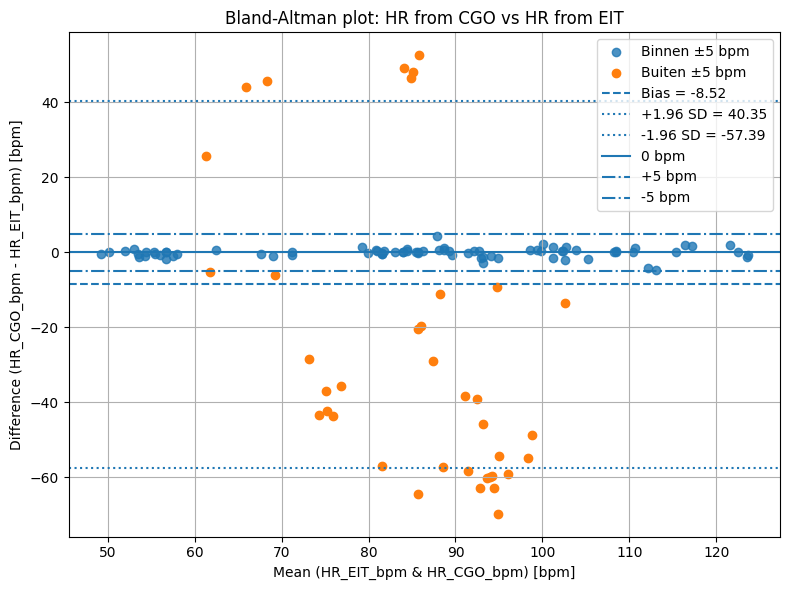

N = 116
Bias: -8.52 bpm
95% LoA: [-57.39, 40.35] bpm
Aantal buiten ±5 bpm: 38
Percentage buiten ±5 bpm: 32.8%


In [11]:
bland_altman_plot(
    csv_path=output_csv,
    save_path=bland_altman_save_path,
    col_ref="HR_EIT_bpm",
    col_test="HR_CGO_bpm",
    sep=";",
    title="Bland-Altman plot: HR from CGO vs HR from EIT",
    filter_condition=lambda df: df["chosen_cgo"] == True,
    show_plot=True
)

## Bland-Altman corrected EIT

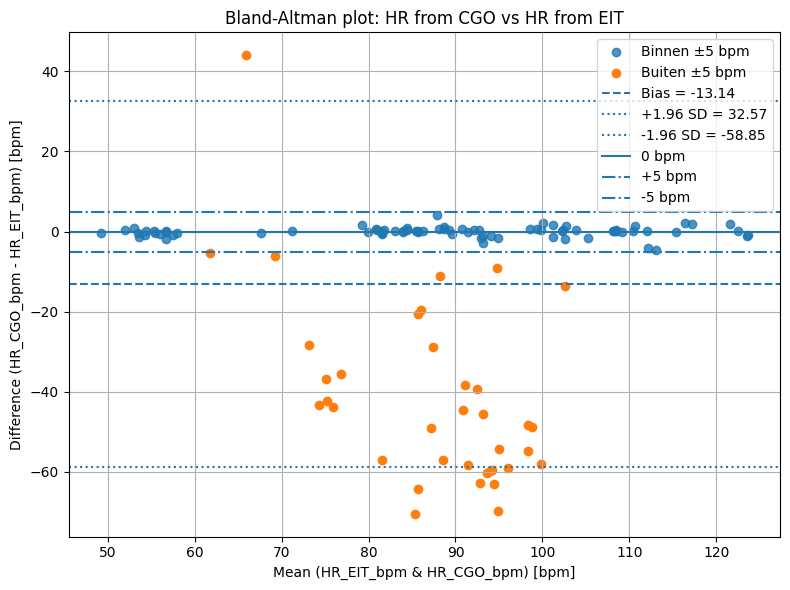

N = 116
Bias: -13.14 bpm
95% LoA: [-58.85, 32.57] bpm
Aantal buiten ±5 bpm: 37
Percentage buiten ±5 bpm: 31.9%


In [12]:
bland_altman_plot(
    csv_path=output_csv_corrected,
    save_path=bland_altman_save_path_corrected,
    col_ref="HR_EIT_bpm",
    col_test="HR_CGO_bpm",
    sep=";",
    title="Bland-Altman plot: HR from CGO vs HR from EIT",
    filter_condition=lambda df: df["chosen_cgo"] == True,
    show_plot=True
)


## Clinical impact

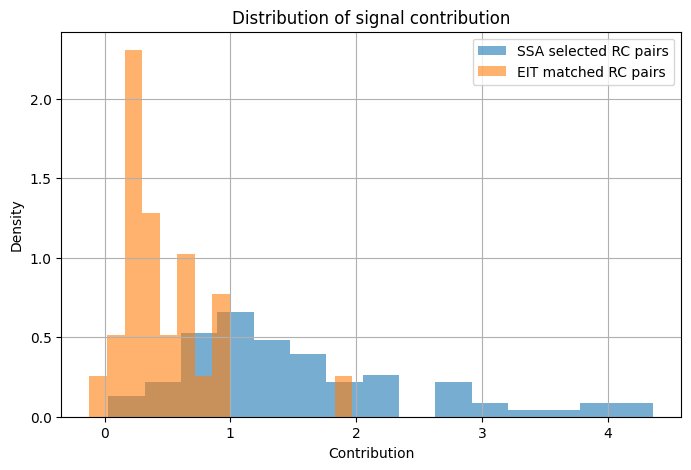

,Patient,Phase,HR CGO,HR EIT,Closest freq.,Freq. diff.,Contribution to signal
0,5,t210,66.16,72.25,65.00,7.25,2.95
1,10,t30,82.62,93.79,87.99,5.80,1.31
2,10,t150,71.91,110.19,104.99,5.20,0.33
3,12,t30,110.09,114.25,105.99,8.26,0.37
4,14,preswitch,54.05,97.80,107.99,10.19,0.24
5,14,t120,64.08,123.90,115.99,7.91,0.32
6,16,t60,67.89,122.04,115.99,6.05,0.21
7,16,t120,70.80,128.82,119.99,8.83,0.14
8,16,t150,62.70,111.63,102.99,8.64,0.83


In [3]:
no_match_summary = run_contribution_to_signal_analysis(
    csv_path=output_csv_corrected,
    output_dir=contribution_results_dir,
    tolerance_bpm=5,
)

no_match_summary